In [ ]:
library(dplyr)
library(egg)
library(ggplot2)
library(ggrastr)
library(grid)
library(gtable)
library(scales)
library(Seurat)
library(SingleCellExperiment)
library(slingshot)
library(stringr)


Attaching package: 'dplyr'


The following object is masked from 'package:nlme':

    collapse


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: gridExtra


Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine


Loading required package: ggplot2

Loading required package: SeuratObject

Loading required package: sp


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: 'matrixStats'


The following object is masked from 'package:dplyr':

    count



Attaching package: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerR

In [3]:
wt <- readRDS("testis-spca.rds")

In [4]:
table(wt$batch)


sample1 sample2 sample3     ss2 
  14827   13931   14696     374 

In [5]:
celltypes <- c(
  "spermatogonium", "mid-late proliferating spermatogonia",
  "spermatogonium-spermatocyte transition", 
  "spermatocyte 0", "spermatocyte 1", "spermatocyte 2", "spermatocyte 3", 
  "spermatocyte 4", "spermatocyte 5", "spermatocyte 6", "spermatocyte 7a", 
  "late primary spermatocyte", "early elongation stage spermatid", 
  "early-mid elongation-stage spermatid", "mid-late elongation-stage spermatid", 
  "adult fat body", "spermatid", "spermatocyte"
)
cells_take <- subset(Cells(wt), wt$ident %in% celltypes)

In [5]:
slingshot.pca <- SingleCellExperiment(list(data=matrix(0, nrow=1, ncol=length(cells_take), dimnames=list("a", cells_take))))
reducedDim(slingshot.pca) <- FetchData(wt, str_glue("PC_{1:21}"), cells = cells_take)
slingshot.pca <- slingshot.pca %>% slingshot()

Dimensionality reduction not explicitly chosen. Continuing with unnamed1

No cluster labels provided. Continuing with one cluster.



In [6]:
slingshot.spca <- SingleCellExperiment(list(data=matrix(0, nrow=1, ncol=length(cells_take), dimnames=list("a", cells_take))))
reducedDim(slingshot.spca) <- FetchData(wt, str_glue("FEATURE_{1:75}"), cells = cells_take)
slingshot.spca <- slingshot.spca %>% slingshot()

Dimensionality reduction not explicitly chosen. Continuing with unnamed1

No cluster labels provided. Continuing with one cluster.



In [10]:
celltypes.cyst <- c(
  "cyst stem cell",
  "early cyst cell 1",
  "early cyst cell 2",
  "cyst cell intermedate",
  "spermatocyte cyst cell branch a",
  "spermatocyte cyst cell branch b",
  "cyst cell branch a",
  "cyst cell branch b",
  "late cyst cell branch a",
  "late cyst cell branch b"
)
cells_take_cyst <- subset(Cells(wt), wt$ident %in% celltypes.cyst)
slingshot.cyst <- SingleCellExperiment(list(data=matrix(0, nrow=1, ncol=length(cells_take_cyst), dimnames=list("a", cells_take_cyst))))
reducedDim(slingshot.cyst) <- FetchData(wt, str_glue("PC_{1:25}"), cells = cells_take_cyst)
slingshot.cyst <- slingshot.cyst %>% slingshot()

ERROR: Error in slingshot(.): could not find function "slingshot"


In [9]:
wt <- wt %>%
  AddMetaData(NA, "slingshot.germ") %>%
  AddMetaData(NA, "slingshot.germ.spca") %>%
  AddMetaData(NA, "slingshot.cyst")
normalize <- \(x) x / max(x)
wt$slingshot.germ[colnames(slingshot.pca)] <- normalize(slingshot.pca$slingPseudotime_1)
wt$slingshot.germ.spca[colnames(slingshot.spca)] <- normalize(slingshot.spca$slingPseudotime_1)
wt$slingshot.cyst[colnames(slingshot.cyst)] <- normalize(slingshot.cyst$slingPseudotime_1)
summary(wt$slingshot.germ)
saveRDS(wt, "tests-spca.rds")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   0.459   0.674   0.556   0.693   1.000   24185 

In [5]:
head(wt@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,ident,technology,batch,pctMito,pctRibo,size_factor,GSC_Score,logXFE,S_Score,S.Score,G2M.Score,Phase,slingshot.germ,slingshot.germ.spca,slingshot.cyst
,<fct>,<dbl>,<int>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
AAACCCACACGGCGTT-6e669170__FCA59_Male_testis_adult_1dWT_Fuller_sample1,SeuratProject,9646,659,male gonad associated epithelium,10x,sample1,0.0000000,3.566245,0.4243299,-1.0591062,0.5926561,NaN,-0.02523764,-0.10372846,G1,NA,NA,NA
AAACCCACATTACTCT-6e669170__FCA59_Male_testis_adult_1dWT_Fuller_sample1,SeuratProject,9101,1044,mid-late elongation-stage spermatid,10x,sample1,1.4943413,3.417207,1.1123150,-1.1660921,-0.8909324,0.00000000,-0.02823945,-0.04801715,G1,0.7889856,0.7879013,NA
AAACCCAGTACGGCAA-6e669170__FCA59_Male_testis_adult_1dWT_Fuller_sample1,SeuratProject,9246,781,spermatid,10x,sample1,0.6705602,3.168938,0.9659079,-1.1186932,-0.8634606,0.00000000,-0.02532672,-0.02264181,G1,0.6633181,0.5720086,NA
AAACCCAGTCGTAATC-6e669170__FCA59_Male_testis_adult_1dWT_Fuller_sample1,SeuratProject,9125,1416,male gonad associated epithelium,10x,sample1,0.5698630,2.882192,0.7726419,-1.1836695,-0.1699696,0.00000000,-0.03662248,-0.15634362,G1,NA,NA,NA
AAACCCAGTCGTATGT-6e669170__FCA59_Male_testis_adult_1dWT_Fuller_sample1,SeuratProject,9156,1285,male gonad associated epithelium,10x,sample1,0.3058104,1.234163,0.7503839,-1.2239022,0.0491721,0.00000000,-0.04381139,-0.04812849,G1,NA,NA,NA
AAACCCAGTGCGACAA-6e669170__FCA59_Male_testis_adult_1dWT_Fuller_sample1,SeuratProject,9744,929,unknown,10x,sample1,0.5747126,3.089080,1.2735567,-0.7609188,-0.2808521,0.02208787,0.03467669,-0.10546973,S,NA,NA,NA


Figuring a figure panel for pseudotime density (identify cell stages)

In [6]:
counts <- readRDS("testis-counts.rds")

Linking to: OpenSSL 3.2.2 4 Jun 2024



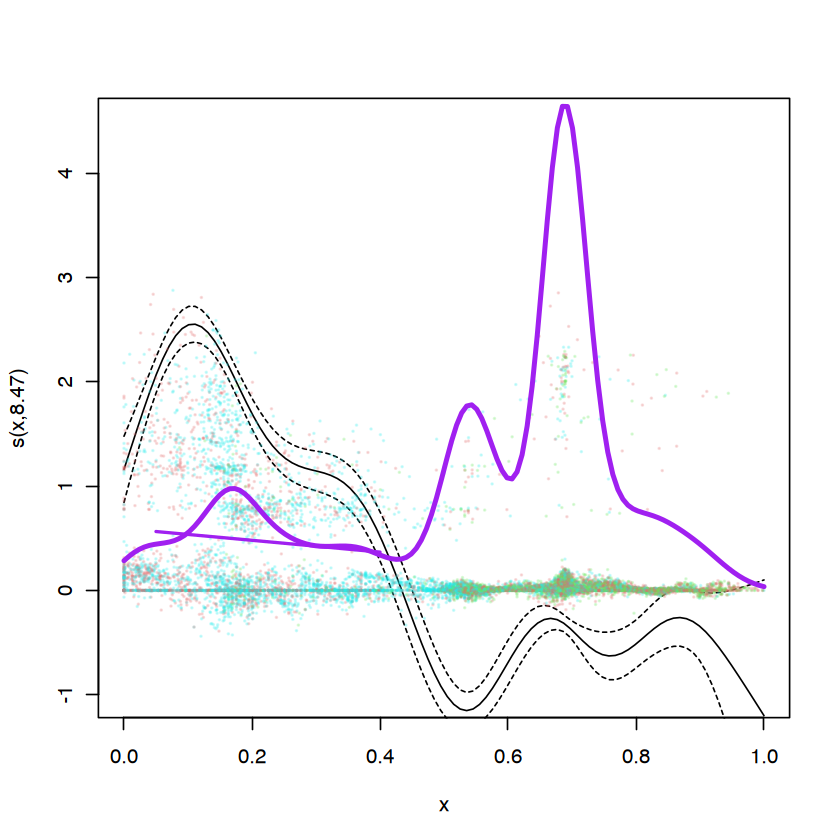

In [7]:
library(mgcv)
plot(
  gam(
    Y ~ s(x) + offset(log(size_factor)) + batch,
    nb(),
    tibble(
      Y = as.numeric(counts["bam", cells_take]),
      dplyr::rename(FetchData(wt, c("slingshot.germ", "size_factor", "batch"), cells = cells_take), x=1),
    )
  ),
  ylim = c(-1, 4.5)
)
library(openssl)
library(tibble)
points(
  rownames_to_column(dplyr::rename(FetchData(wt, c("slingshot.germ", "bam"), cells = cells_take), x=1, y=2)) %>% arrange(md5(rowname)) %>% subset(select=-rowname),
  col = c("G1" = "#68e95c33", "G2M" = "#26ebeb33", "S" = "#e46c6c33")[pull(FetchData(wt, "Phase", cells=cells_take))][
    # with(FetchData(wt, "Phase", cells=cells_take), order(Phase != "G1", Phase != "G2M", Phase != "S"))
    order(md5(cells_take))
  ],
  pch = 19,
  cex = 0.1
)
dens.fit <- density(pull(FetchData(wt, "slingshot.germ", cells=cells_take)), adjust = 1.5, from = 0, to = 1, n = 128)
dens.broad <- density(pull(FetchData(wt, "slingshot.germ", cells=cells_take)), bw = 0.1, from = 0, to = 1, n = 128)
lines(
  dens.fit,
  col = "purple",
  lwd = 3
)
x <- 0.3
dydx <- diff(dens.broad$y)[which.max(dens.broad$x >= x)] / diff(dens.broad$x)[which.max(dens.broad$x >= x)]
x <- 0.3
y <- dens.fit$y[which.max(dens.broad$x >= x)]
dx <- c(-0.25, 0.1)
lines(
  x + dx,
  y + dx * dydx,
  col = "purple",
  lwd = 2
)

In [8]:
(score.print <- dens.fit$x[1 + which(diff(sign(diff(dens.fit$y))) < 0)] %>%
  subset(between(dens.fit$y[match(., dens.fit$x)], 0.75, 7)))

[1] 0.1732283 0.5433071 0.6850394

In [9]:
(score <- dens.fit$y[match(score.print, dens.fit$x)] %>% `/`(head(., 1)))

[1] 1.000000 1.821706 4.751970

In [10]:
exp(log(score) - mean(log(score) - log(c(1, 2, 4))))

[1] 0.9740458 1.7744247 4.6286361

In [11]:
sum((log(score) - mean(log(score) - log(c(1, 2, 4))) - log(c(1, 2, 4)))^2)

[1] 0.03631929

In [12]:
table(
  FetchData(
    wt, "Phase",
    cells = FetchData(wt, "slingshot.germ") %>%
      subset(between(slingshot.germ, 0.38, 0.4)) %>%
      rownames()
  ) %>%
    pull()
)

Warning message:
"Removing 24185 cells missing data for vars requested"



 G1 G2M   S 
  6  97  32 

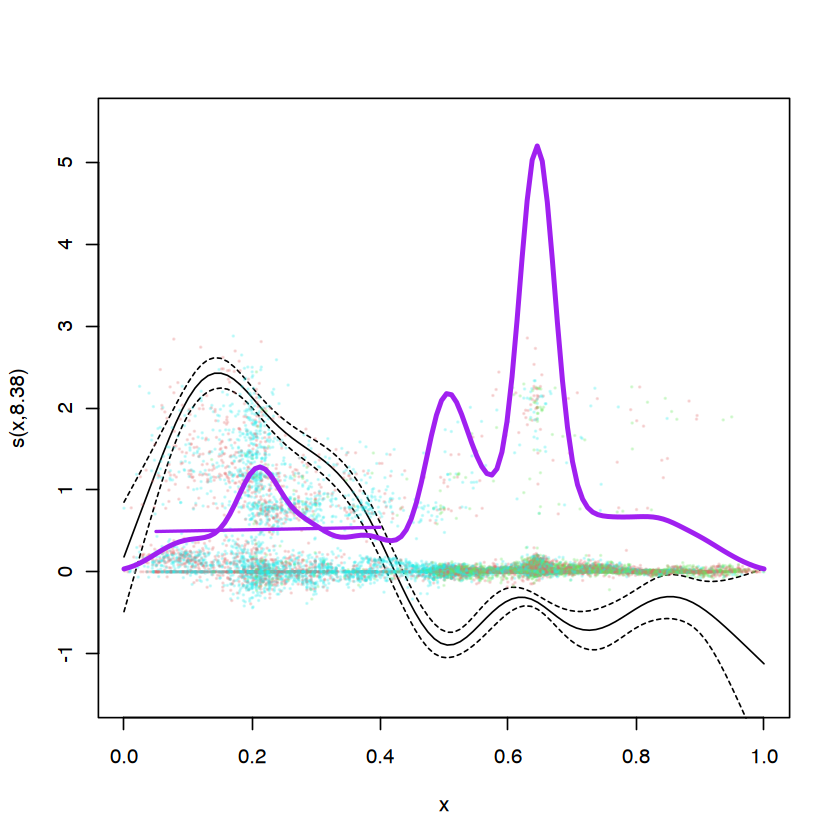

In [419]:
library(mgcv)
plot(
  gam(
    Y ~ s(x) + offset(log(size_factor)) + batch,
    nb(),
    tibble(
      Y = as.numeric(counts["bam", cells_take]),
      dplyr::rename(FetchData(wt, c("slingshot.germ.spca", "size_factor", "batch"), cells = cells_take), x=1),
    )
  ),
  ylim = c(-1.5, 5.5)
)
library(openssl)
library(tibble)
points(
  rownames_to_column(dplyr::rename(FetchData(wt, c("slingshot.germ.spca", "bam"), cells = cells_take), x=1, y=2)) %>% arrange(md5(rowname)) %>% subset(select=-rowname),
  col = c("G1" = "#68e95c33", "G2M" = "#26ebeb33", "S" = "#e46c6c33")[pull(FetchData(wt, "Phase", cells=cells_take))][
    # with(FetchData(wt, "Phase", cells=cells_take), order(Phase != "G1", Phase != "G2M", Phase != "S"))
    order(md5(cells_take))
  ],
  pch = 19,
  cex = 0.1
)
dens.fit <- density(pull(FetchData(wt, "slingshot.germ.spca", cells=cells_take)), adjust = 1.5, from = 0, to = 1, n = 128)
dens.broad <- density(pull(FetchData(wt, "slingshot.germ.spca", cells=cells_take)), bw = 0.1, from = 0, to = 1, n = 128)
lines(
  dens.fit,
  col = "purple",
  lwd = 3
)
x <- 0.3
dydx <- diff(dens.broad$y)[which.max(dens.broad$x >= x)] / diff(dens.broad$x)[which.max(dens.broad$x >= x)]
x <- 0.3
y <- dens.fit$y[which.max(dens.broad$x >= x)]
dx <- c(-0.25, 0.1)
lines(
  x + dx,
  y + dx * dydx,
  col = "purple",
  lwd = 2
)

In [420]:
dydx

[1] 0.1447148

In [421]:
(score.print <- dens.fit$x[1 + which(diff(sign(diff(dens.fit$y))) < 0)] %>%
  subset(between(dens.fit$y[match(., dens.fit$x)], 1, 7)))

[1] 0.2125984 0.5039370 0.6456693

In [422]:
(score <- dens.fit$y[match(score.print, dens.fit$x)] %>% `/`(head(., 1)))

[1] 1.000000 1.699280 4.061663

In [423]:
exp(log(score) - mean(log(score) - log(c(1, 2, 4))))

[1] 1.050446 1.785002 4.266558

In [424]:
sum((log(score) - mean(log(score) - log(c(1, 2, 4))) - log(c(1, 2, 4)))^2)

[1] 0.01951805

Creating a figure of spermatogonia density & spermatocyte/spermatid density

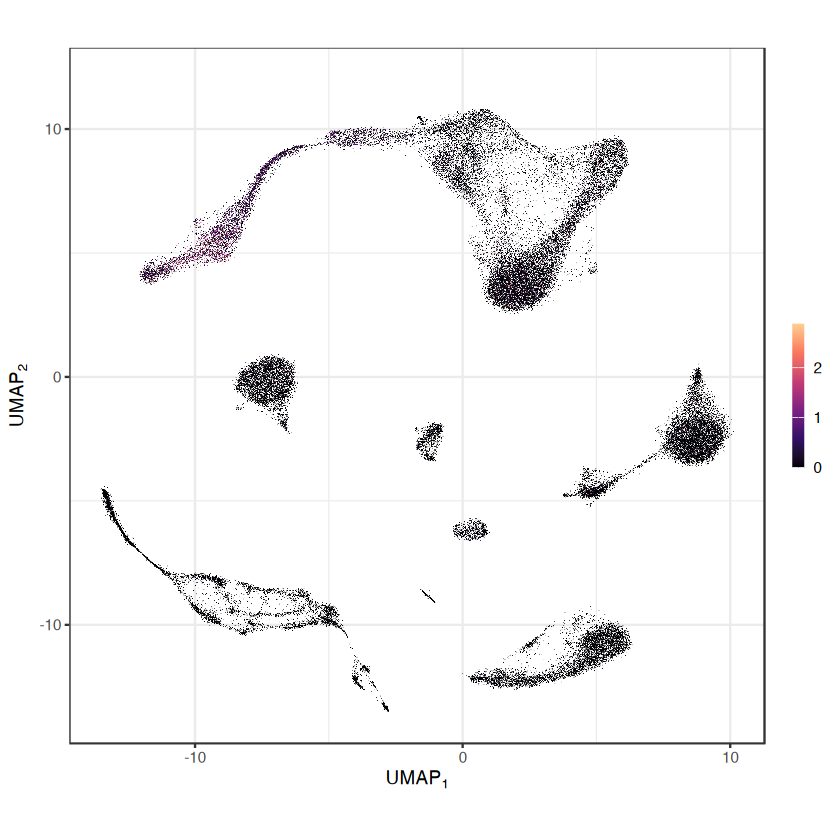

In [487]:
dpi <- 600
xmin <- -13
ymin <- 2
xmax <- 7
ymax <- 12
(
  figA <- FetchData(wt, c("UMAP_1", "UMAP_2", "bam")) %>%
    dplyr::rename(UMAP_1=2, UMAP_2=1, feature=3) %>%
    ggplot(aes(-UMAP_1, -UMAP_2, color=feature)) +
    rasterise(geom_point(data = \(data) data %>% arrange(feature), stroke=NA, size=0.2), dpi = dpi) +
    geom_blank(data = tibble(UMAP_1 = -c(xmin, xmax), UMAP_2 = -c(ymin, ymax), feature = 0)) +
    scale_x_continuous(breaks = c(-10, 0, 10)) +
    scale_y_continuous(breaks = c(-10, 0, 10)) +
    scale_color_viridis_c(option = "magma", end = 0.9, limits = c(0, NA), oob = squish) +
    labs(x = bquote(UMAP[1]), y = bquote(UMAP[2])) +
    guides(
      color = guide_colorbar(NULL, barwidth = 0.5, barheight = 6)
    ) +
    theme_bw() +
    theme(aspect.ratio = 1)
)

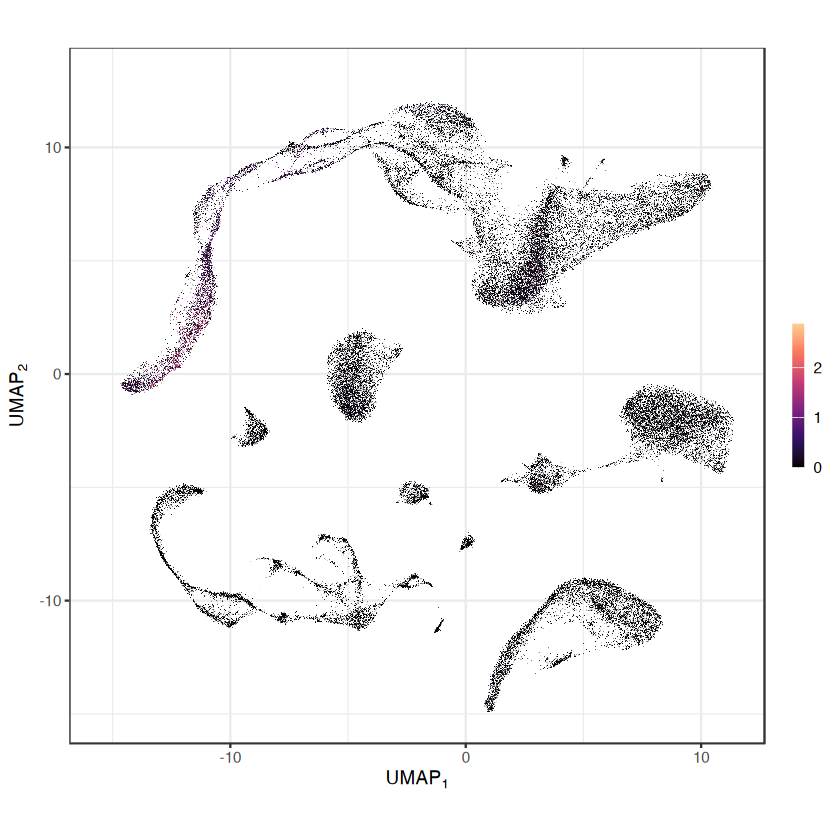

In [13]:
dpi <- 600
xmin <- -15.5
ymin <- -2
xmax <- 11
ymax <- 13
(
  figA <- FetchData(wt, c("umap.pca_1", "umap.pca_2", "bam")) %>%
    dplyr::rename(UMAP_1=2, UMAP_2=1, feature=3) %>%
    ggplot(aes(-UMAP_1, -UMAP_2, color=feature)) +
    rasterise(geom_point(data = \(data) data %>% arrange(feature), stroke=NA, size=0.2), dpi = dpi) +
    geom_blank(data = tibble(UMAP_1 = -c(xmin, xmax), UMAP_2 = -c(ymin, ymax), feature = 0)) +
    scale_x_continuous(breaks = c(-10, 0, 10)) +
    scale_y_continuous(breaks = c(-10, 0, 10)) +
    scale_color_viridis_c(option = "magma", end = 0.9, limits = c(0, NA), oob = squish) +
    labs(x = bquote(UMAP[1]), y = bquote(UMAP[2])) +
    guides(
      color = guide_colorbar(NULL, barwidth = 0.5, barheight = 6)
    ) +
    theme_bw() +
    theme(aspect.ratio = 1)
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


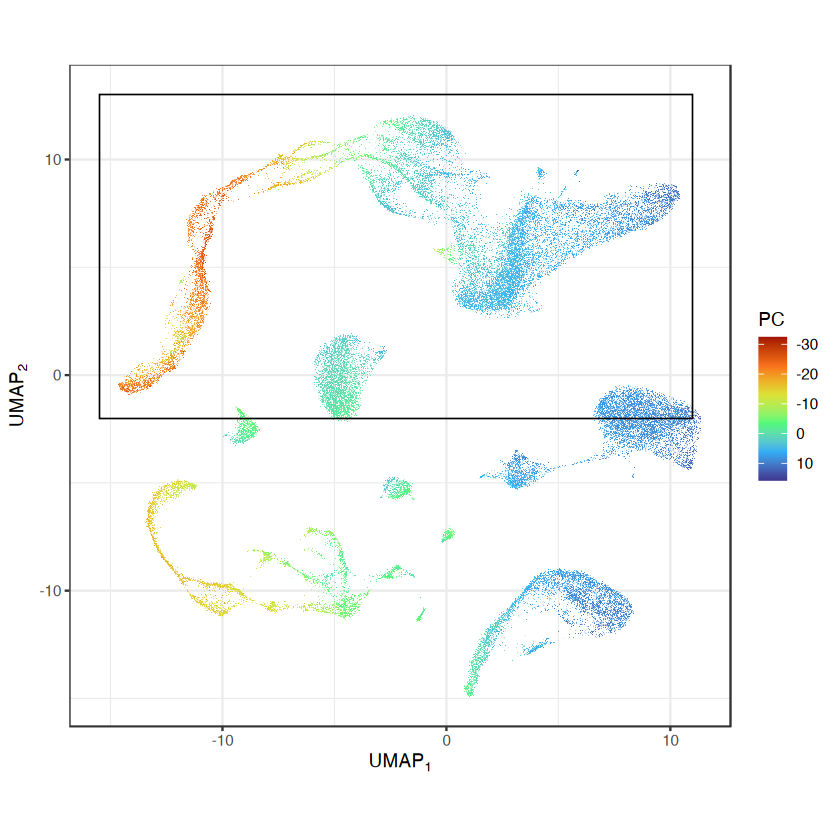

In [21]:
{
  figB <- figA +
    annotate(
      "rect",
      xmin = xmin, ymin = ymin, xmax = xmax, ymax = ymax,
      fill = "transparent",
      color = "black",
      linewidth = 25.4 / 72
    )
  figB$data$feature <- pull(FetchData(wt, "PC_2"))
  figB <- figB +
    scale_color_viridis_c(option = "turbo", begin = 0.05, end = 0.95, direction = -1) +
    guides(color = guide_colorbar("PC", reverse = T))
  figB
}

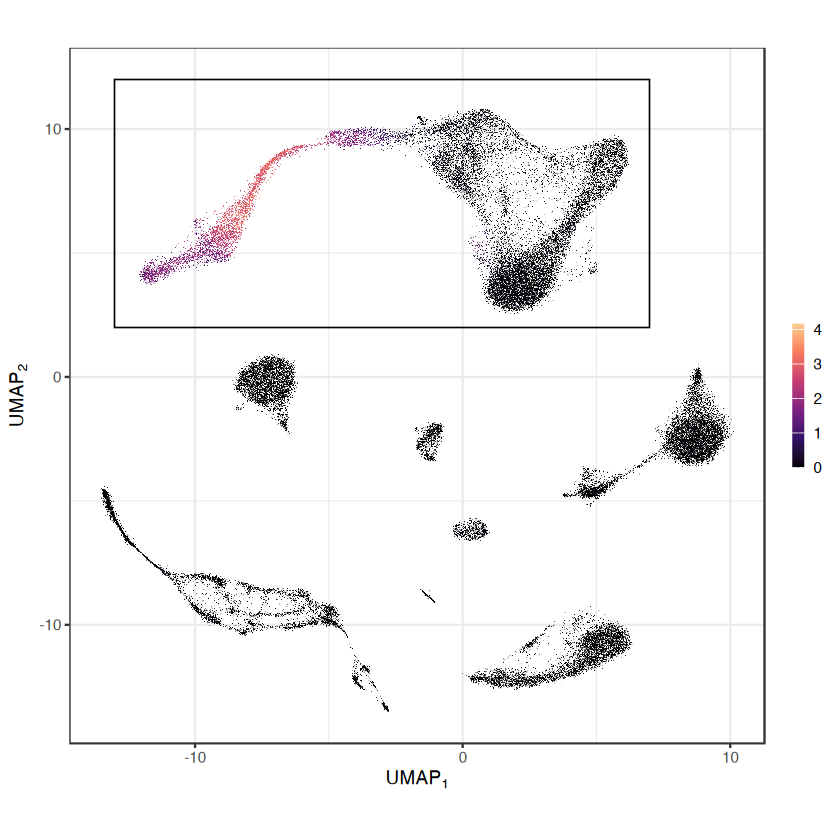

In [488]:
{
  figB <- figA +
    annotate(
      "rect",
      xmin = xmin, ymin = ymin, xmax = xmax, ymax = ymax,
      fill = "transparent",
      color = "black",
      linewidth = 25.4 / 72
    )
  figB$data$feature <- pull(FetchData(wt, "FEATURE_10")) / sum(wt[["spca"]]@feature.loadings[, 10])
  figB
}

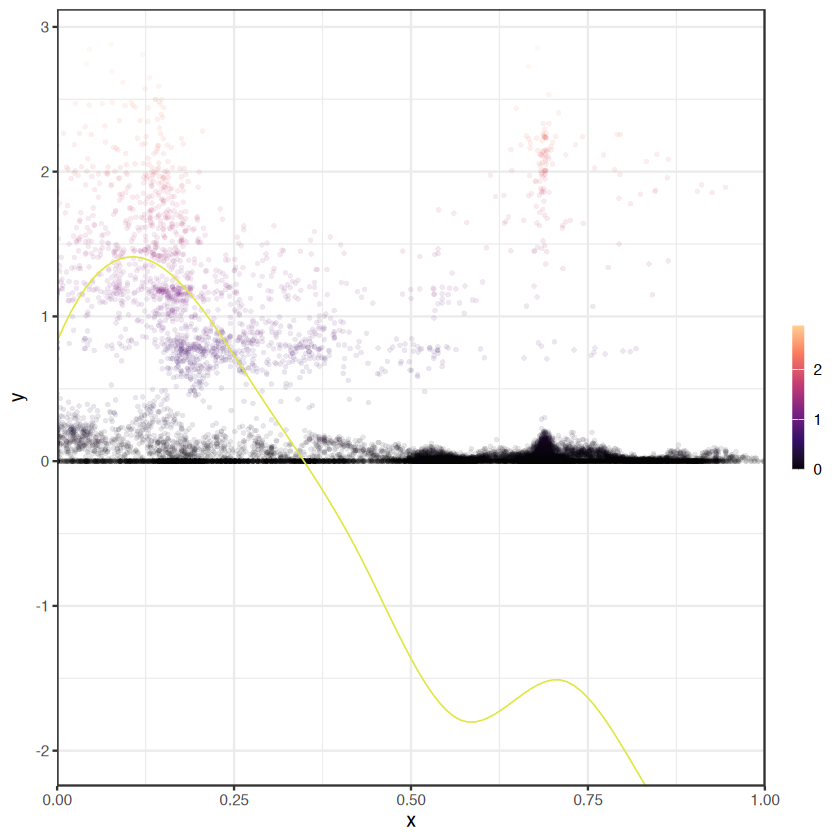

In [22]:
pseudotime_x <- scale_x_continuous(breaks = c(0, 0.25, 0.5, 0.75, 1))
pseudotime_limits <- c((1 - 1/1.1)/2 - 1e-4, 1 - (1 - 1/1.1)/2)
figC <- tibble(
  dplyr::rename(
    FetchData(
      wt,
      c("slingshot.germ", "bam", "batch", "nCount_RNA"),
      cells = cells_take
    ),
    x=1,
    y=2
  ),
  y.umi = counts["bam", cells_take]
) %>%
  ggplot(
    aes(x, y)
  ) +
  rasterise(
    geom_point(aes(color=y), data = \(data) data %>% mutate(y = pmax(0, y)), stroke = NA, alpha = 0.1),
    dpi = dpi
  ) +
  scale_color_viridis_c(option = "magma", end = 0.9) +
  geom_line(
    data = \(data) {
      model <- mgcv::gam(
        y.umi ~ s(x, bs = "bs", by = batch) + offset(log(nCount_RNA) - log(10000)),
        nb(),
        data
      )
      tibble(
        x = seq(0, 1, by=0.01),
        pseudolog = mean(y) - log(exp(mean(y)) - 1),
        y = rowMeans(
          sapply(
            c("sample1", "sample2", "sample3", "ss2"),
            \(n) predict(
              model,
              newdata = data.frame(x = x, batch = n, nCount_RNA = 10000)
            )
          )
        ) +
          pseudolog,
      )
    },
    col = "#e0e642",
    linewidth = 25.4 / 72
  ) +
  pseudotime_x +
  guides(
    color = guide_colorbar(NULL, barwidth = 0.5, barheight = 6)
  ) +
  coord_cartesian(pseudotime_limits, c(-2, NA)) +
  theme_bw()
figC

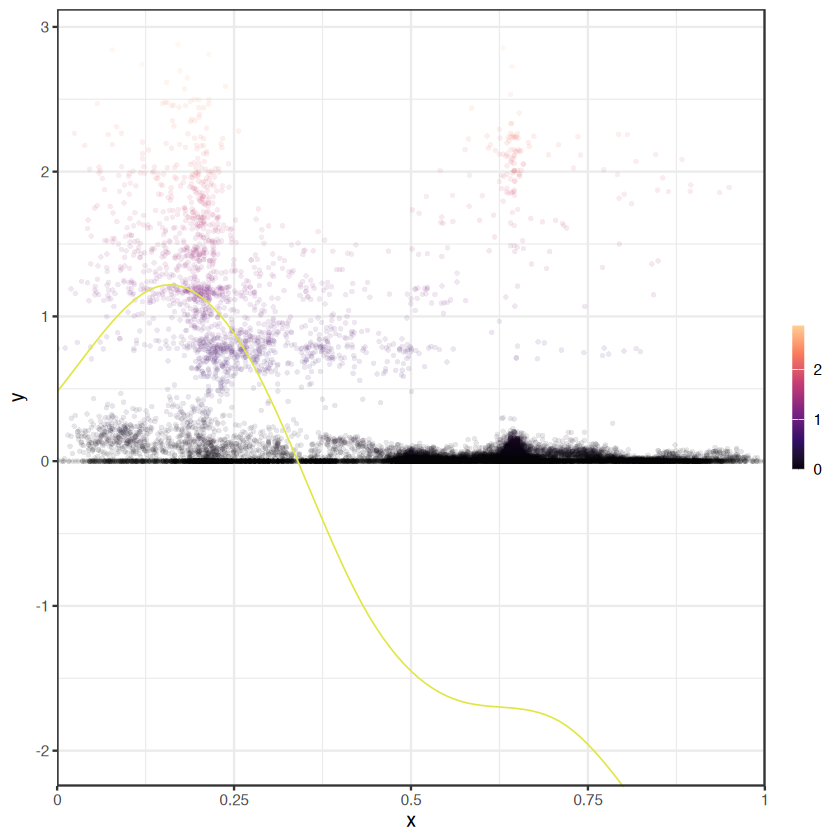

In [503]:
pseudotime_x <- scale_x_continuous(breaks = c(0, 0.25, 0.5, 0.75, 1), labels = as.character)
pseudotime_limits <- c((1 - 1/1.1)/2 - 1e-4, 1 - (1 - 1/1.1)/2)
figC <- tibble(
  dplyr::rename(
    FetchData(
      wt,
      c("slingshot.germ.spca", "bam", "batch", "nCount_RNA"),
      cells = cells_take
    ),
    x=1,
    y=2
  ),
  y.umi = counts["bam", cells_take]
) %>%
  ggplot(
    aes(x, y)
  ) +
  rasterise(
    geom_point(aes(color=y), data = \(data) data %>% mutate(y = pmax(0, y)), stroke = NA, alpha = 0.1),
    dpi = dpi
  ) +
  scale_color_viridis_c(option = "magma", end = 0.9) +
  geom_line(
    data = \(data) {
      model <- mgcv::gam(
        y.umi ~ s(x, bs = "bs", by = batch) + offset(log(nCount_RNA) - log(10000)),
        nb(),
        data
      )
      tibble(
        x = seq(0, 1, by=0.01),
        pseudolog = mean(y) - log(exp(mean(y)) - 1),
        y = rowMeans(
          sapply(
            c("sample1", "sample2", "sample3", "ss2"),
            \(n) predict(
              model,
              newdata = data.frame(x = x, batch = n, nCount_RNA = 10000)
            )
          )
        ) +
          pseudolog,
      )
    },
    col = "#e0e642",
    linewidth = 25.4 / 72
  ) +
  pseudotime_x +
  guides(
    color = guide_colorbar(NULL, barwidth = 0.5, barheight = 6)
  ) +
  coord_cartesian(pseudotime_limits, c(-2, NA)) +
  theme_bw()
figC

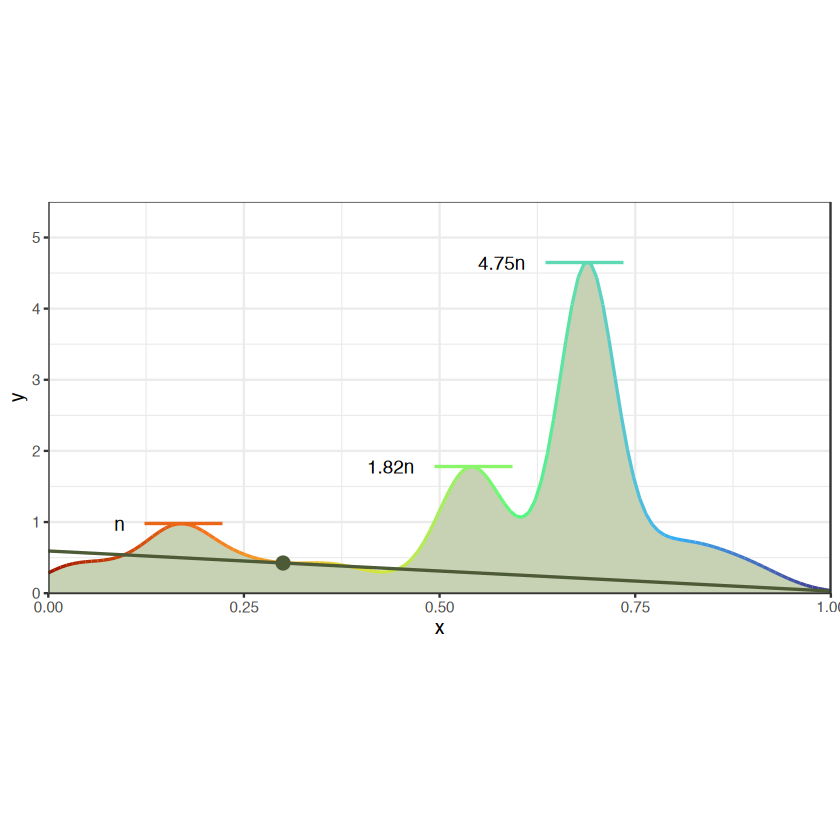

In [23]:
figD <- ggplot(
  as_tibble(dens.fit[c("x", "y")]),
  aes(x, y)
) +
  geom_polygon(
    data = \(data) data %>%
      add_row(x = 1, y = 0) %>%
      add_row(x = 0, y = 0),
    fill = "#c7d2b5"
  ) +
  geom_segment(
    aes(xend = xend, yend = yend, color = color),
    \(data) with(
      data,
      tibble(
        x = head(x, length(x) - 1),
        y = head(y, length(y) - 1),
        xend = tail(data$x, length(data$x) - 1),
        yend = tail(data$y, length(data$y) - 1),
        color = (x + xend) / 2,
      )
    ),
    linewidth = 2 * 25.4 / 72,
  ) +
  geom_segment(
    aes(xend = xend, yend = yend, color = color),
    \(data) with(
      dplyr::slice(data, intersect(1 + which(diff(sign(diff(y))) == -2), which(y >= 0.75))),
      as_tibble(
        list(
          x = x - 0.05,
          xend = x + 0.05,
          y = y,
          yend = y,
          color = x
        )
      )
    ),
    linewidth = 2 * 25.4 / 72,
  ) +
  geom_path(
    aes(group = 1),
    \(data) {
      x <- 0.3
      dydx <- diff(dens.broad$y)[which.max(dens.broad$x >= x)] / diff(dens.broad$x)[which.max(dens.broad$x >= x)]
      x <- 0.3
      y <- dens.fit$y[which.max(dens.broad$x >= x)]
      dx <- c(-0.3, 0.7)
      tibble(x = x + dx, y = y + dx * dydx)
    },
    color = "#4c5a36",
    linewidth = 2 * 25.4 / 72,
  ) +
  geom_point(
    data = \(data) tibble(x = 0.3, y = data$y[which.max(data$x >= 0.3)]),
    color = "#4c5a36",
    stroke = NA,
    size = 4,
  ) +
  geom_text(
    aes(label = label),
    \(data) with(
      dplyr::slice(data, intersect(1 + which(diff(sign(diff(y))) == -2), which(y >= 0.75))),
      as_tibble(
        list(
          x = x - 0.075,
          y = y,
          label = paste0(
            c(
              "",
              round(y[2:3] / y[1], 2)
            ),
            "n"
          )
        )
      )
    ),
    family = "Helvetica",
    hjust = 1,
    vjust = 0.5
  ) +
  scale_color_viridis_c(option = "turbo", direction = -1, begin = 0.05, end = 0.95, limits = c(0, 1), na.value = "#cccccc") +
  pseudotime_x +
  coord_cartesian(c(0, 1), c(0, 5.5), expand = FALSE) +
  guides(color = guide_none()) +
  theme_bw() +
  theme(aspect.ratio = 1/2)
figD

In [24]:
dplyr::slice(
  as_tibble(dens.fit[c("x", "y")]),
  intersect(1 + which(diff(sign(diff(y))) == -2), which(y >= 0.75))
)

x,y
<dbl>,<dbl>
0.1732283,0.9772513
0.5433071,1.7802642
0.6850394,4.6438687


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


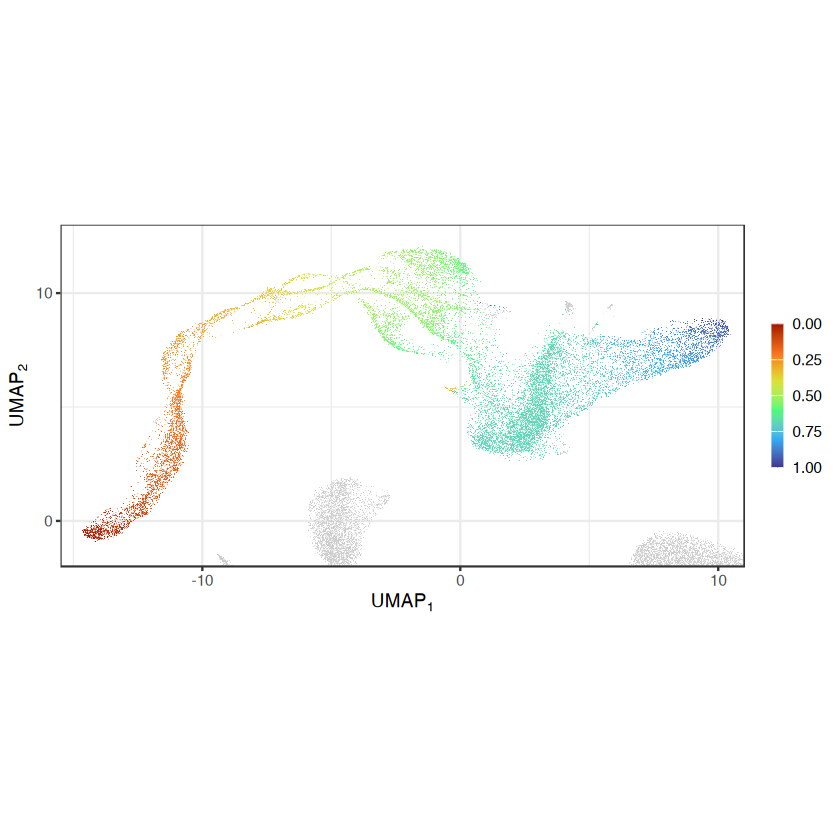

In [25]:
{
  figE <- figA +
    scale_color_viridis_c(option = "turbo", direction = -1, begin = 0.05, end = 0.95, na.value = "#cccccc") +
    coord_cartesian(c(xmin, xmax), c(ymin, ymax), expand = FALSE) +
    guides(color = guide_colorbar(NULL, reverse = T, barwidth = 0.5, barheight = 6)) +
    theme(aspect.ratio = 1/2)
  figE$data$feature <- NA
  figE$data$feature[match(cells_take, rownames(figE$data))] <- pull(FetchData(wt, "slingshot.germ", cells = cells_take))
  figE
}

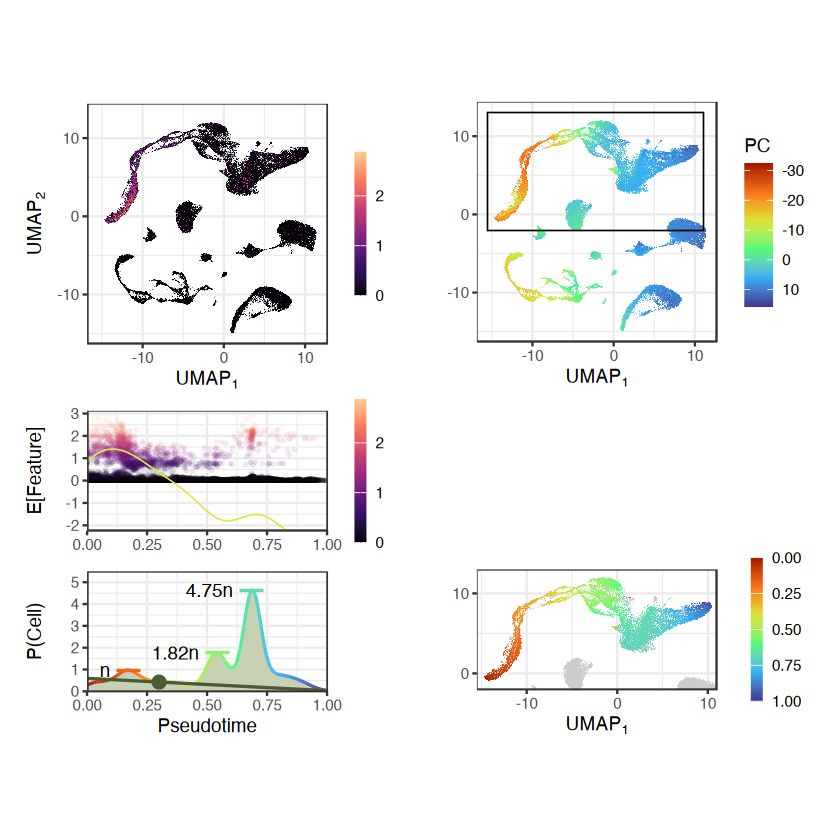

In [26]:
panelA <- set_panel_size(figA, w = unit(2, "in"), h= unit(2, "in"))
panelC <- set_panel_size(figC + labs(x = NULL, y = "E[Feature]"), w = unit(2, "in"), h = unit(1, "in"))
panelD <- set_panel_size(figD + labs(x = "Pseudotime", y = "P(Cell)"), w = unit(2, "in"), h = unit(1, "in"))

panelB <- set_panel_size(
  figB + labs(y = NULL) +
    theme(
      plot.margin = margin(5.5, 5.5, as.numeric(convertUnit(sum(panelC$heights), "pt")) + 5.5, 5.5),
    ),
  w = unit(2, "in"), h= unit(2, "in")
)
panelE <- set_panel_size(
  figE + labs(y = NULL),
  w = unit(2, "in"), h = unit(1, "in")
)
grid.draw(
  gtable(unit(c(3.5, 3.5), "in"), unit(1, "null")) %>%
    gtable_add_grob(
      list(
        rbind(panelA, panelC, panelD),
        rbind(panelB, panelE)
      ),
      t = 1,
      l = 1:2
    )
)

In [27]:
ggsave(
  "PseudotimeFigure.pdf",
(
  gtable(unit(c(3.5, 3.5), "in"), unit(1, "null")) %>%
    gtable_add_grob(
      list(
        rbind(panelA, panelC, panelD),
        rbind(panelB, panelE)
      ),
      t = 1,
      l = 1:2
    )
),
w = 6.75,
h = 6
)

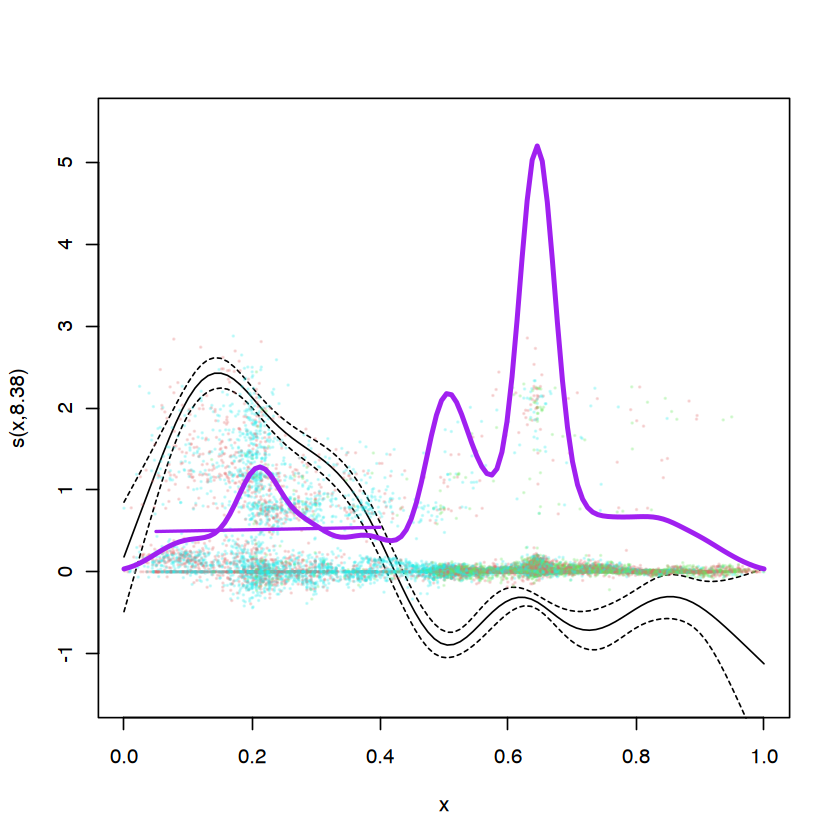

In [485]:
library(mgcv)
plot(
  gam(
    Y ~ s(x) + offset(log(size_factor)) + batch,
    nb(),
    tibble(
      Y = as.numeric(counts["bam", cells_take]),
      dplyr::rename(FetchData(wt, c("slingshot.germ.spca", "size_factor", "batch"), cells = cells_take), x=1),
    )
  ),
  ylim = c(-1.5, 5.5)
)
library(openssl)
library(tibble)
points(
  rownames_to_column(dplyr::rename(FetchData(wt, c("slingshot.germ.spca", "bam"), cells = cells_take), x=1, y=2)) %>% arrange(md5(rowname)) %>% subset(select=-rowname),
  col = c("G1" = "#68e95c33", "G2M" = "#26ebeb33", "S" = "#e46c6c33")[pull(FetchData(wt, "Phase", cells=cells_take))][
    # with(FetchData(wt, "Phase", cells=cells_take), order(Phase != "G1", Phase != "G2M", Phase != "S"))
    order(md5(cells_take))
  ],
  pch = 19,
  cex = 0.1
)
dens.fit <- density(pull(FetchData(wt, "slingshot.germ.spca", cells=cells_take)), adjust = 1.5, from = 0, to = 1, n = 128)
dens.broad <- density(pull(FetchData(wt, "slingshot.germ.spca", cells=cells_take)), bw = 0.1, from = 0, to = 1, n = 128)
lines(
  dens.fit,
  col = "purple",
  lwd = 3
)
x <- 0.3
dydx <- diff(dens.broad$y)[which.max(dens.broad$x >= x)] / diff(dens.broad$x)[which.max(dens.broad$x >= x)]
x <- 0.3
y <- dens.fit$y[which.max(dens.broad$x >= x)]
dx <- c(-0.25, 0.1)
lines(
  x + dx,
  y + dx * dydx,
  col = "purple",
  lwd = 2
)

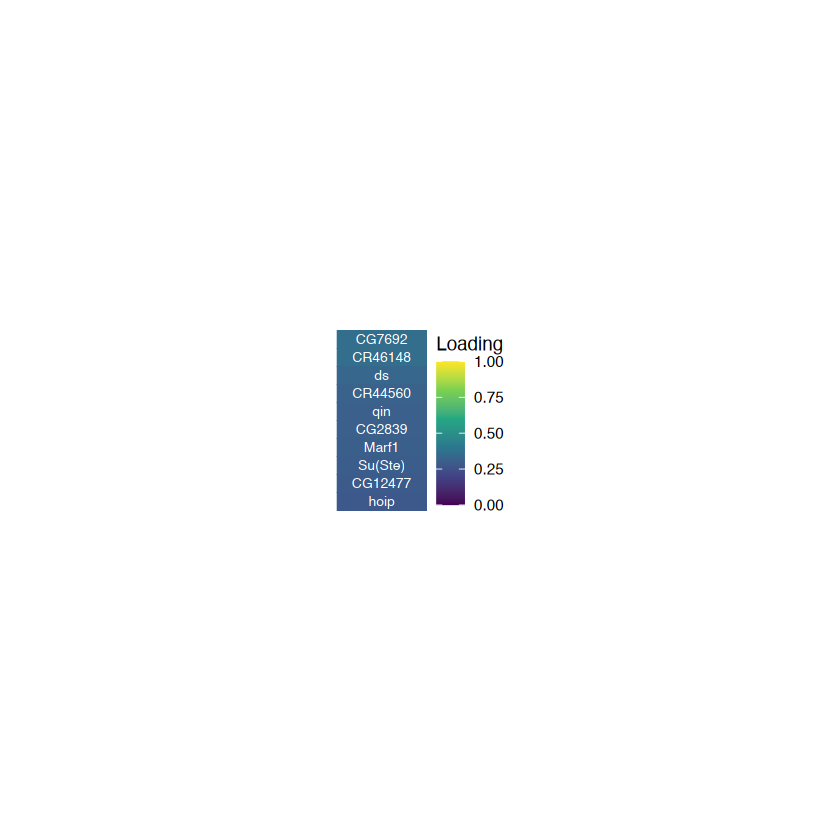

In [517]:
panelSpcaTable <- set_panel_size(
  ggplot(
    tibble(
      enframe(wt[["spca"]]@feature.loadings[, 10] %>% subset(. != 0) %>% sort(dec=T)),
      row = seq_along(name),
    ),
    aes(x = 0, y = row, label = name, fill = value)
  ) +
    geom_tile() +
    geom_text(
      data = \(data) data %>%
        mutate(
          name = name %>%
            str_replace("lncRNA:", "") %>%
            replace(grep("Su\\(Ste\\)", .), "Su(Ste)")
        ),
      size = 8 * 25.4 / 72,
      fontface = "bold",
      color = "white",
    ) +
    scale_y_reverse() +
    scale_fill_viridis_c(
      "Loading",
      limits=c(0,1),
      na.value='#000000'
    ) +
    coord_cartesian(expand = FALSE) +
    theme_void(),
  w = unit(0.75, "in"),
  h = unit(1.5, "in")
)
grid.draw(panelSpcaTable)

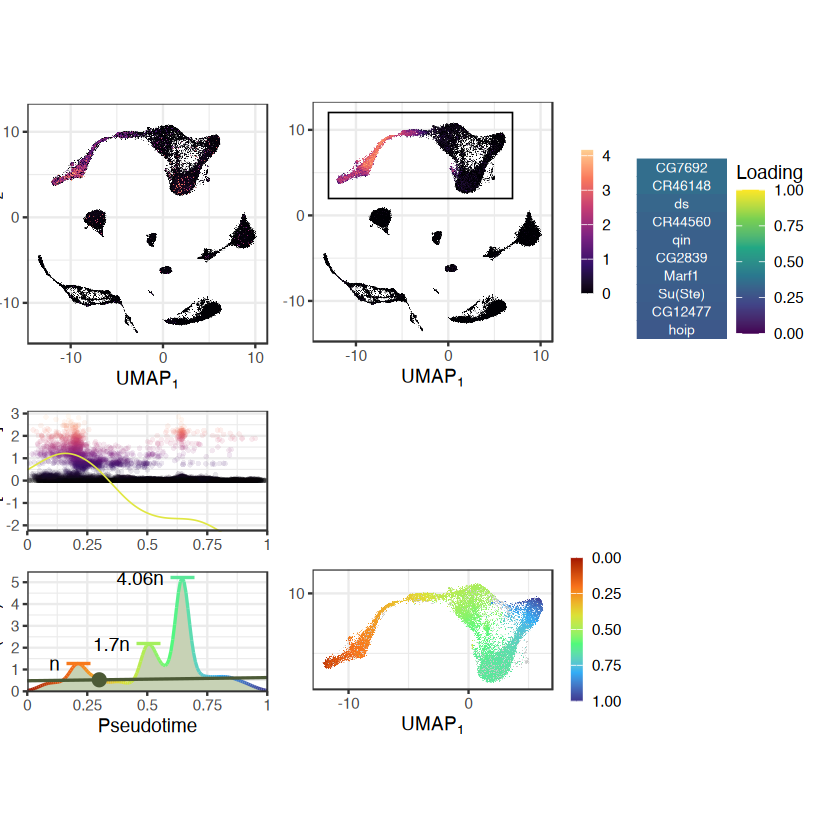

In [ ]:
shrink_margin <- theme(
  axis.title.y = element_text(margin = margin(0, -8, 0, 0)),
  plot.margin = margin(5.5, 0, 5.5, 0),
  legend.margin = margin(0, 0, 0, 0),
  legend.box.margin = margin(0, 0, 0, 0),
)
panelA <- set_panel_size(figA + shrink_margin, w = unit(2, "in"), h= unit(2, "in"))
panelC <- set_panel_size(figC + shrink_margin + labs(x = NULL, y = "E[Feature]"), w = unit(2, "in"), h = unit(1, "in"))
panelD <- set_panel_size(figD + shrink_margin + labs(x = "Pseudotime", y = "P(Cell)"), w = unit(2, "in"), h = unit(1, "in"))

panelB <- set_panel_size(
  figB + labs(y = NULL) +
    shrink_margin +
    theme(
      plot.margin = margin(5.5, 0, as.numeric(convertUnit(sum(panelC$heights), "pt")) + 5.5, 0),
    ),
  w = unit(2, "in"), h= unit(2, "in")
)
panelE <- set_panel_size(
  figE + labs(y = NULL) + shrink_margin,
  w = unit(2, "in"), h = unit(1, "in")
)

grid.draw(
  figure <- gtable(unit(c(2.5, 2.5), "in"), unit(1, "null")) %>%
    gtable_add_grob(
      list(
        rbind(panelA, panelC, panelD),
        rbind(panelB, panelE)
      ),
      t = 1,
      l = 1:2
    )
)

In [534]:
ggsave("SPCAFig6.pdf", figure, w = 6.5, h = 6.5)